In [81]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
path = "results/{0}_fig7_rho_sub_critical_test_3.p"
#N_range = [int(n) for n in np.geomspace(1e5, 3e6, 10)]
N_range = [ 100000,  145923,  212936, 310723]
num_ensambles = 1024
M = np.empty((len(N_range), num_ensambles))

In [102]:
for n in range(num_ensambles):
    with open(path.format(n), "rb") as f:
        mags = pickle.load(f)
        print(mags)
        for N in range(len(N_range)):
            m = mags[N]
            M[N,n] = m

[0.05135815456287335, 0.44838, 0.05009928457178902, 0.02797365733982991]
[0.0444264943457189, 0.43707, 0.04441898411125021, 0.024444398758249213]
[0.058040913701769545, 0.0302, 0.04156113322798763, 0.03457302824092158]
[0.45456850884772887, 0.05043, 0.45011473241440125, 0.05557040356900557]
[0.03076041627531277, 0.03205, 0.03635714124799259, 0.03037218258944786]
[0.03912443175414209, 0.448, 0.4402345497436624, 0.019647348259013316]
[0.0547676297103355, 0.03126, 0.025286187375894286, 0.43460592230148776]
[0.03463012360521471, 0.4371, 0.4332379643605398, 0.03233897329413458]
[0.043181988954427625, 0.02159, 0.039282576442683674, 0.024122311081871947]
[0.05759477025960852, 0.06464, 0.0383846705908478, 0.03915763793233418]
[0.4488062140737123, 0.44862, 0.45262822513943285, 0.022224049670031457]
[0.040162302288011424, 0.01756, 0.018032137949234528, 0.036813936116993205]
[0.4332428523124319, 0.03085, 0.44010259942134955, 0.022977871891339954]
[0.04221456212195213, 0.06334, 0.4494002696935856,

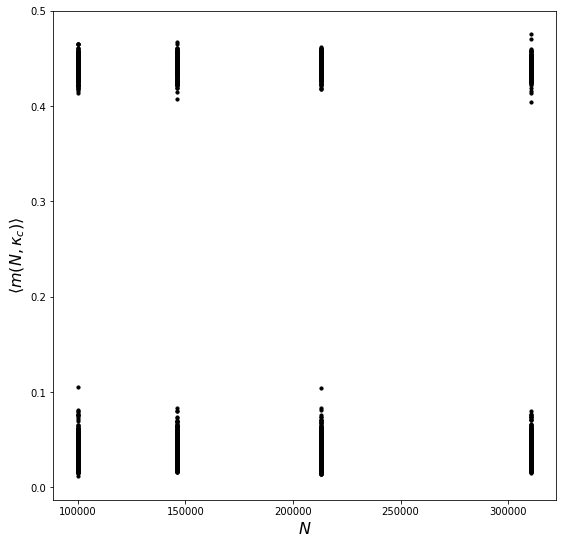

In [113]:
plt.figure(figsize=(9,9))
for n in range(num_ensambles):
    plt.scatter(N_range, M[:, n], s=10,c='k')
plt.xlabel(r'$N$', fontsize=16)
plt.ylabel(r'$\langle m(N, \kappa_c)\rangle$', fontsize=16)
plt.show()

In [115]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= ms.size//4:
        pairs.append([N_range[N], 0.0559263564072972-np.mean(md), np.std(md)])
        
pairs = np.array(pairs)

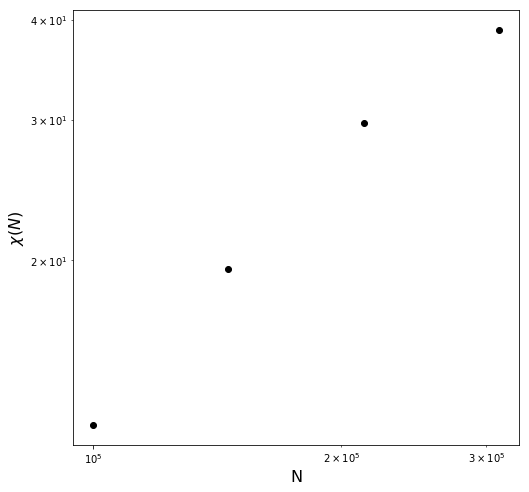

In [114]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= 0:#ms.size//4:
        pairs.append([N_range[N], N_range[N]*(np.mean(md**2)-np.mean(md)**2)])
        
pairs = np.array(pairs)
plt.figure(figsize=(8,8))
plt.loglog(*pairs[:,:2].T, 'ko')
plt.xlabel('N', fontsize=16)
plt.ylabel(r'$\chi (N)$', fontsize=16)
plt.show()

In [110]:
z = np.polyfit(np.log(pairs[:, 0]), np.log(pairs[:, 1]), 1)
print(z)
p = np.poly1d(z)

[ 1.01694285 -9.14882542]


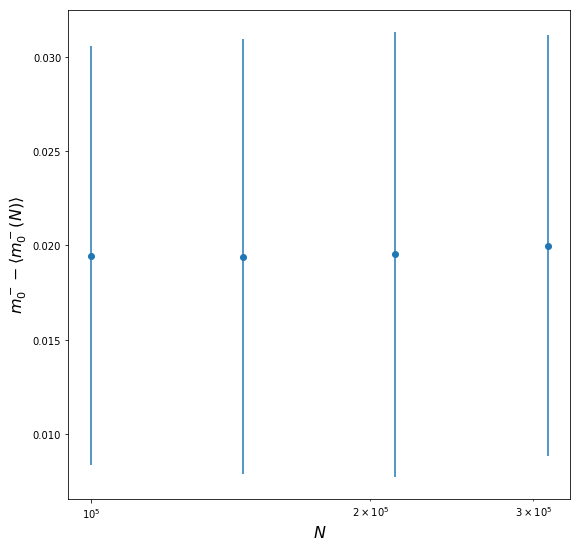

In [116]:
plt.figure(figsize=(9,9))
plt.errorbar(*pairs[:, :2].T, yerr=pairs[:, 2], fmt='o')
#plt.plot(pairs[:, 0], p(np.log(pairs[:, 0])))
plt.ylabel(r'$m_0^--\langle m_0^-(N)\rangle$', fontsize=16)
plt.xlabel(r'$N$', fontsize=16)
plt.xscale('log')
#plt.yscale('log')
plt.show()

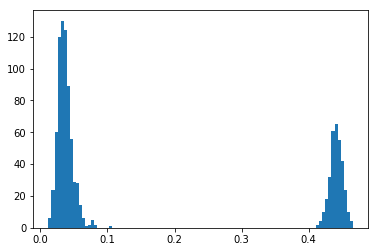

In [108]:
plt.hist(M[0,:], bins=100)
plt.show()